<a href="https://colab.research.google.com/github/EasierJohn/Responsible-Machine-Learning-/blob/main/Individual_Assign1_Easier_John.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

Acknowledge AI: Generative AI (Google Gemini and ChatCPT) was used as a supplementary aid to support understanding of responsible machine learning concepts and assist with reproducing the R code to Python code. In line with principles of transparency and accountability, all modeling decisions, implementation, and analysis were independently reviewed and completed by me, Easier John.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

In [ ]:
# Load the dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Rows in dataset:", len(raw_data))

Rows in dataset: 7214


In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [ ]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Filtering
df = df[
    (df['days_b_screening_arrest'].between(-30, 30)) &
    (df['is_recid'] != -1) &
    (df['c_charge_degree'] != "O") &
    (df['score_text'] != "N/A")
]

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors='coerce')

cols_to_factorize = [col for col in df.columns if col not in numeric_vars and col not in datetime_vars]
for col in cols_to_factorize:
    if df[col].dtype != 'datetime64[ns, UTC]':
        df[col] = df[col].astype('category')

df['crime_factor'] = df['c_charge_degree'].astype('category')

df['age_factor'] = df['age_cat'].astype('category')

df['race_factor'] = df['race'].astype('category')

df['gender_factor'] = df['sex'].astype('category')

df['score_factor'] = pd.Categorical(np.where(df['score_text'] != 'Low', 'HighScore', 'LowScore'))

# Get the number of rows
print(len(df))

6172


In [ ]:
df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore


In [ ]:
def glimpse(df):
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    for col in df.columns:
        dtype = df[col].dtype


        if "int" in str(dtype):
            dtype_str = "<int>"
        elif "float" in str(dtype):
            dtype_str = "<dbl>"
        elif "datetime" in str(dtype):
            dtype_str = "<dttm>"
        else:
            dtype_str = "<fct>"

        values = [str(x) for x in df[col].head(12)]
        values_str = ", ".join(values)

        if len(df[col]) > 12:
            values_str += "…"

        print(f"$ {col:<23} {dtype_str:<6} {values_str}")

glimpse(df)

Rows: 6,172
Columns: 18
$ age                     <int>  69, 34, 24, 44, 41, 43, 39, 27, 23, 37, 41, 47…
$ c_charge_degree         <fct>  F, F, F, M, F, F, M, F, M, M, F, F…
$ race                    <fct>  Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian, African-American, Caucasian…
$ age_cat                 <fct>  Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, Greater than 45…
$ score_text              <fct>  Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low, Low, Low…
$ sex                     <fct>  Male, Male, Male, Male, Male, Male, Female, Male, Male, Female, Male, Female…
$ priors_count            <int>  0, 0, 4, 0, 14, 3, 0, 0, 3, 0, 0, 1…
$ days_b_screening_arrest <dbl>  -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0, -1.0, -20.0…
$ decile_score            <int>  1, 3, 4, 1, 6, 4, 1, 4, 6, 1, 4, 1…
$ is_recid                

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [ ]:
df["length_of_stay"] = (
    pd.to_datetime(df["c_jail_out"].astype(str).str[:10]) -
    pd.to_datetime(df["c_jail_in"].astype(str).str[:10])
).dt.days

df[["length_of_stay", "decile_score"]].corr().iloc[0, 1]

np.float64(0.20732969161470416)

After filtering we have the following demographic breakdown:

In [ ]:
print(df["age_cat"].value_counts())

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [ ]:
print(df['race'].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [ ]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [ ]:
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [ ]:
print(df['sex'].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [ ]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [ ]:
num_recid = len(df[df['two_year_recid'] == 1])
print(f"Number of defendants with two-year recidivism: {num_recid}")

Number of defendants with two-year recidivism: 2809


In [ ]:
percentage_recid = (num_recid / len(df)) * 100
print(f"Percentage of defendants with two-year recidivism: {percentage_recid:.5f}%")

Percentage of defendants with two-year recidivism: 45.51199%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

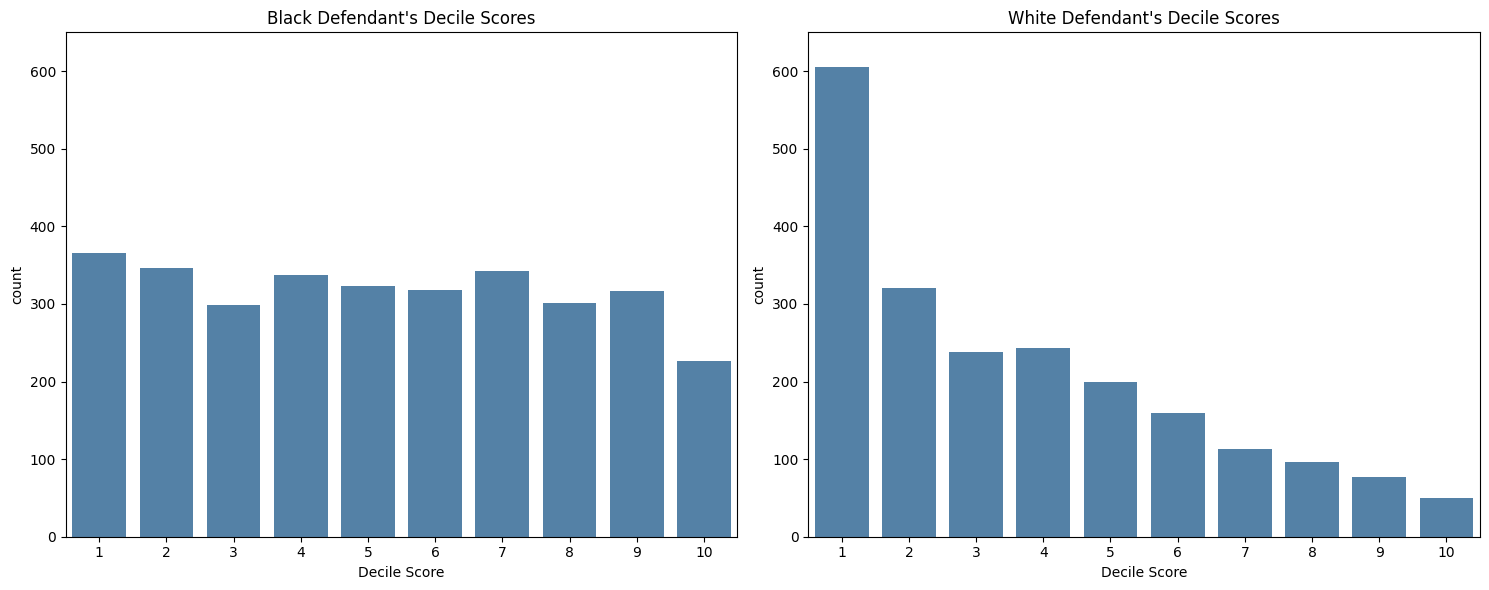

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for African-American defendants
sns.countplot(x='decile_score', data=df[df['race'] == 'African-American'], ax=axes[0], color='steelblue')
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

# Plot for Caucasian defendants
sns.countplot(x='decile_score', data=df[df['race'] == 'Caucasian'], ax=axes[1], color='steelblue')
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [ ]:
print(pd.crosstab(df['decile_score'], df['race']))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [ ]:
df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)

df['age_factor'] = pd.Categorical(
    df['age_cat'],
    categories=['25 - 45', 'Greater than 45', 'Less than 25']
)

df['gender_factor'] = pd.Categorical(
    df['sex'],
    categories=['Male', 'Female']
)

race_categories_ordered = ['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
df['race_factor'] = pd.Categorical(
    df['race'],
    categories=race_categories_ordered
)

crime_categories = ['F'] + [c for c in df['c_charge_degree'].unique() if c != 'F']
df['crime_factor'] = pd.Categorical(
    df['c_charge_degree'],
    categories=crime_categories
)

formula_str = """
score_binary ~ C(gender_factor)
             + C(age_factor)
             + C(race_factor)
             + priors_count
             + C(crime_factor)
             + two_year_recid
"""

model = smf.logit(formula_str, data=df).fit()


print(model.summary())

pd.reset_option('display.float_format')

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        02:46:55   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))
print(f"result: {result:.7g}")

result: 1.452841


Women are 19.4% more likely than men to get a higher score.

In [ ]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))
print(f"{result:.7g}")

1.194798


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))
print(f"{result:.7g}")

2.49612


In [ ]:
import numpy as np

# Calculate predicted probabilities using the fitted model
df['pred_prob'] = model.predict(df)

# Classify predictions based on a 0.5 threshold
df['pred_class_numeric'] = np.where(df['pred_prob'] >= 0.5, 1, 0)

# Convert the numeric classification to a categorical variable with specified labels
df['pred_class'] = pd.Categorical(
    df['pred_class_numeric'],
    categories=[0, 1],
    ordered=False
).rename_categories(['No Recid', 'Recid'])

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

actual_values = df['two_year_recid'].astype(int)
predicted_values = df['pred_class_numeric'].astype(int)

# Generate the confusion matrix. sklearn's confusion_matrix returns [[TN, FP], [FN, TP]]
# for binary classification where 0 is negative and 1 is positive.
cm_sklearn = confusion_matrix(actual_values, predicted_values, labels=[0, 1])

# Extract TN, FP, FN, TP
TN = cm_sklearn[0, 0]
FP = cm_sklearn[0, 1]
FN = cm_sklearn[1, 0]
TP = cm_sklearn[1, 1]

#                 Actual
# Predicted    0          1
#   No Recid   TN         FN
#   Recid      FP         TP
overall_cm_py = pd.DataFrame({
    '0': [TN, FP], # Actual 0
    '1': [FN, TP]  # Actual 1
}, index=['No Recid', 'Recid'])
overall_cm_py.columns.name = 'Actual'
overall_cm_py.index.name = 'Predicted'
print(overall_cm_py)

# Calculate overall metrics
n = TP + TN + FP + FN

accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN) # False Positive Rate
fnr = FN / (FN + TP) # False Negative Rate

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [ ]:
import pandas as pd
import numpy as np

print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────")

# Ensure actual and predicted are numeric for calculations
# 'two_year_recid' is categorical with '0' and '1' as categories, so astype(int) works.
actual = df['two_year_recid'].astype(int)
pred = df['pred_class_numeric'].astype(int)

def calculate_race_metrics(group_df):
    n = len(group_df)
    TP = ((group_df['pred'] == 1) & (group_df['actual'] == 1)).sum()
    TN = ((group_df['pred'] == 0) & (group_df['actual'] == 0)).sum()
    FP = ((group_df['pred'] == 1) & (group_df['actual'] == 0)).sum()
    FN = ((group_df['pred'] == 0) & (group_df['actual'] == 1)).sum()

    # Calculate metrics, handling potential division by zero with np.nan
    accuracy = (TP + TN) / n if n > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan

    return pd.Series({
        'n': n,
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'Accuracy': round(accuracy, 3),
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'FPR': round(fpr, 3),
        'FNR': round(fnr, 3)
    })

# Create a temporary DataFrame with 'actual' and 'pred' for grouping
temp_df = df.copy()
temp_df['actual'] = actual
temp_df['pred'] = pred

race_metrics = temp_df.groupby('race').apply(calculate_race_metrics).reset_index()

# Arrange by 'n' in descending order
race_metrics = race_metrics.sort_values(by='n', ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────
               race       n      TP      TN     FP     FN  Accuracy  \
0  African-American  3175.0  1373.0   959.0  555.0  288.0     0.734   
2         Caucasian  2103.0   381.0  1148.0  133.0  441.0     0.727   
3          Hispanic   509.0    81.0   306.0   14.0  108.0     0.760   
5             Other   343.0    22.0   216.0    3.0  102.0     0.694   
1             Asian    31.0     2.0    22.0    1.0    6.0     0.774   
4   Native American    11.0     5.0     2.0    4.0    0.0     0.636   

   Precision  Recall    FPR    FNR  
0      0.712   0.827  0.367  0.173  
2      0.741   0.464  0.104  0.536  
3      0.853   0.429  0.044  0.571  
5      0.880   0.177  0.014  0.823  
1      0.667   0.250  0.043  0.750  
4      0.556   1.000  0.667  0.000  


/tmp/ipykernel_2767/3021892967.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_metrics = temp_df.groupby('race').apply(calculate_race_metrics).reset_index()
/tmp/ipykernel_2767/3021892967.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_metrics = temp_df.groupby('race').apply(calculate_race_metrics).reset_index()


In [ ]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

# Select relevant columns
disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()

# Get FPR and FNR for Caucasian race (reference)
caucasian_fpr = disparity.loc[disparity['race'] == 'Caucasian', 'FPR'].iloc[0]
caucasian_fnr = disparity.loc[disparity['race'] == 'Caucasian', 'FNR'].iloc[0]

# Calculate delta_FPR and delta_FNR
disparity['delta_FPR'] = round(disparity['FPR'] - caucasian_fpr, 3)
disparity['delta_FNR'] = round(disparity['FNR'] - caucasian_fnr, 3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────
               race       n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175.0  0.367  0.173      0.263     -0.363
2         Caucasian  2103.0  0.104  0.536      0.000      0.000
3          Hispanic   509.0  0.044  0.571     -0.060      0.035
5             Other   343.0  0.014  0.823     -0.090      0.287
1             Asian    31.0  0.043  0.750     -0.061      0.214
4   Native American    11.0  0.667  0.000      0.563     -0.536


STEP 0 - Train / test split

In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target based on the previous logistic regression model
features = [
    'gender_factor',
    'age_factor',
    'race_factor',
    'priors_count',
    'crime_factor',
    'two_year_recid'
]
target = 'score_binary'

X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


Step 1 — Fit logistic regression and gradient-boosted tree

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical features based on the 'features' list
numeric_features = ['priors_count']
category_features = [
    'gender_factor',
    'age_factor',
    'race_factor',
    'crime_factor',
    'two_year_recid'
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM-- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor',
                                                   'two_year_recid'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

Step 2 — Compare model performance by race

In [ ]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"],
            gdf["pred"]
        ).ravel()

        # Handle potential division by zero for metrics
        accuracy = round(accuracy_score(gdf["actual"], gdf["pred"]), 3)
        fpr = round(fp / (fp + tn), 3) if (fp + tn) > 0 else 0.0
        fnr = round(fn / (fn + tp), 3) if (fn + tp) > 0 else 0.0
        auc = round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": accuracy,
            "FPR": fpr,
            "FNR": fnr,
            "AUC": auc,
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test, group_col="race_factor"))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test, group_col="race_factor"))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
2             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
2             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


/tmp/ipykernel_2767/694071662.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):
/tmp/ipykernel_2767/694071662.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):


Step 3 — LIME explanations: Black vs White defendant

In [ ]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# Ensure lime is installed
!pip install lime

X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (
        numeric_features +
        list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))
    ),
    class_names = ["No Recid", "Recid"],
    mode = "classification",
    discretize_continuous= True,
    random_state = 42
)

# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Filter for African-American defendants and sort by predicted probability
black_defendants = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
# Get the index of the middle element within this filtered group
black_idx = black_defendants.index[len(black_defendants) // 2]

# Filter for Caucasian defendants and sort by predicted probability
white_defendants = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")
# Get the index of the middle element within this filtered group
white_idx = white_defendants.index[len(white_defendants) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn= gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3368
 age_factor_Greater than 45 <= 0.00       +0.2173
 0.00 < race_factor_African-American <= 1.00 +0.1094
 -0.47 < priors_count <= 0.17             -0.0901
 race_factor_Hispanic <= 0.00             +0.0820
 two_year_recid_0 <= 0.00                 +0.0416

 LIME: White defendant 
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4171
 age_factor_Less than 25 <= 0.00          -0.3528
 -0.68 < priors_count <= -0.47            -0.2735
 age_factor_Greater than 45 <= 0.00       +0.2316
 race_factor_African-American <= 0.00     -0.1128
 two_year_recid_1 <= 0.00                 -0.0448


Step 4 — SHAP beeswarm and waterfall: Black vs White

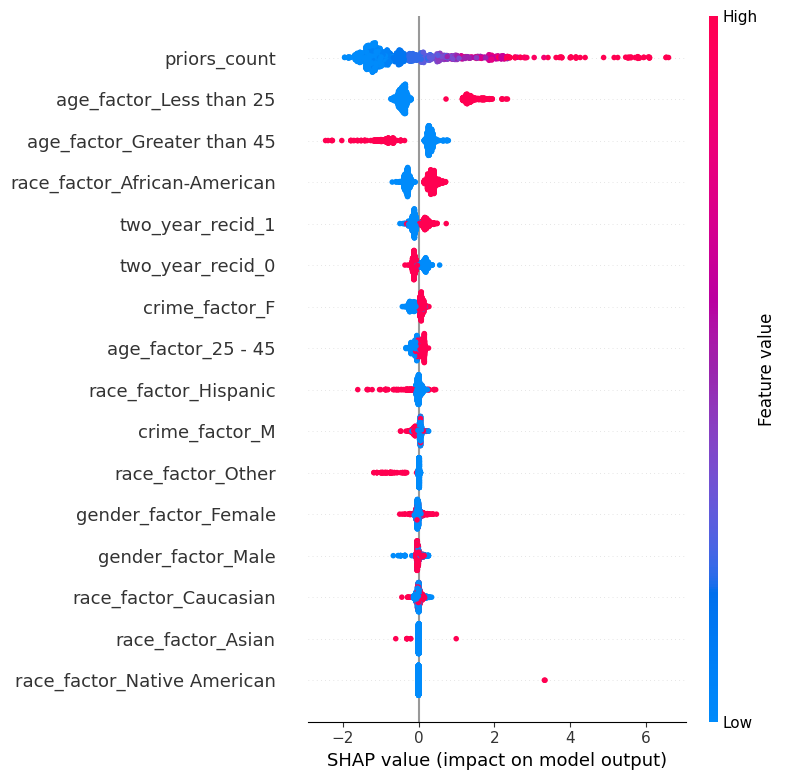

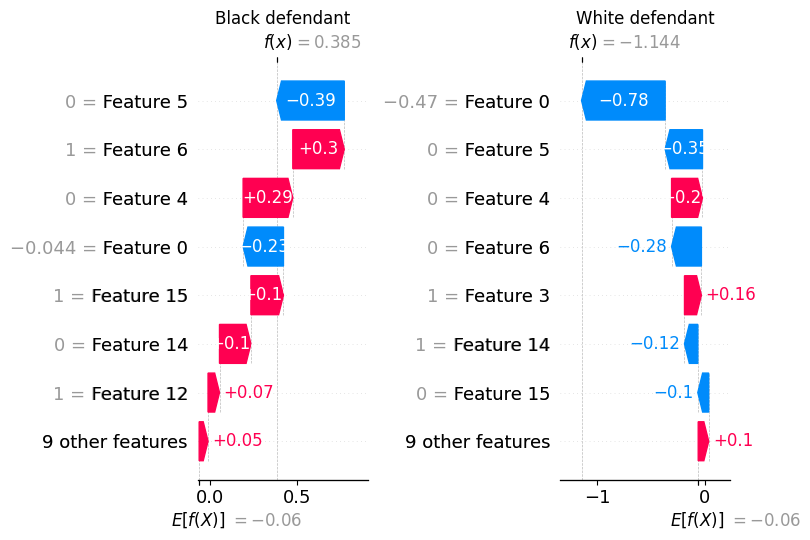

In [ ]:
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (
    numeric_features +
    list(preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
feature_names=feat_names)
# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
        max_display=8,
        show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

 93%|=================== | 1146/1235 [00:14<00:01]       

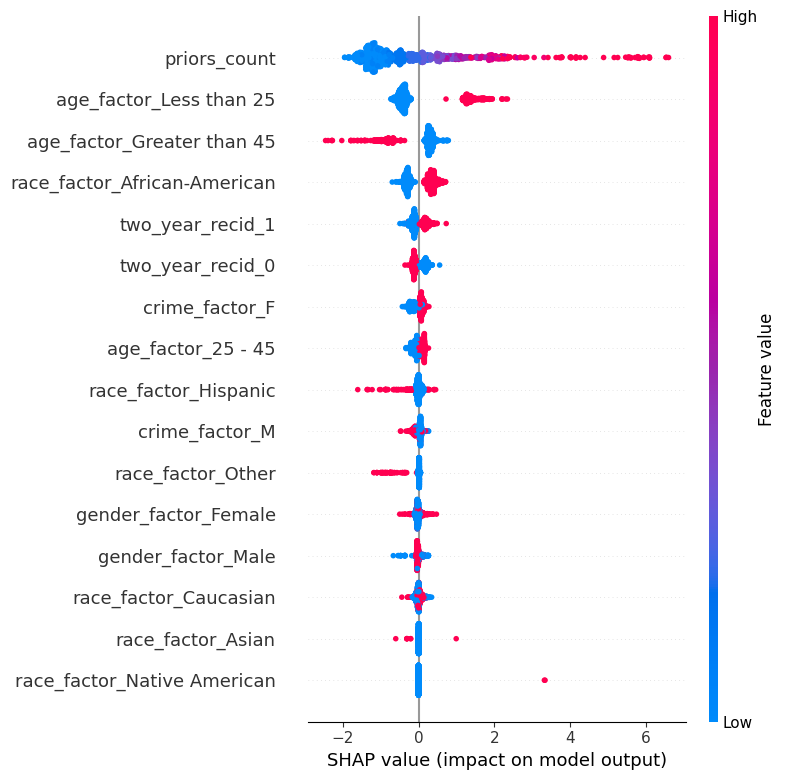

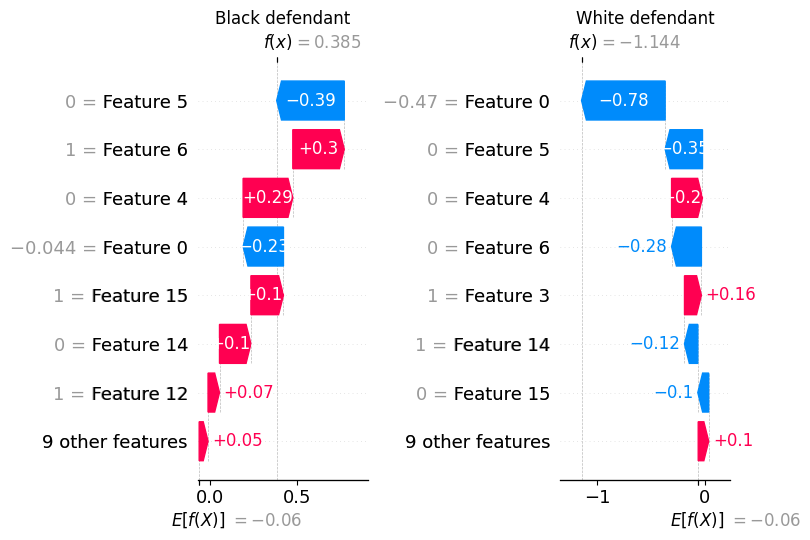

In [ ]:
# !pip install shap
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (numeric_features +
list(preprocessor
.named_transformers_["cat"]
.get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
gbt_pipeline["classifier"],
shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
feature_names=feat_names)
# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
(axes[0], black_loc, "Black defendant"),
(axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
    max_display=8,
    show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

Step 5 — Counterfactuals with DiCE: Black vs White

In [ ]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
dataframe = pd.concat([X_train, y_train], axis=1),
continuous_features = numeric_features,
outcome_name = target
)
dice_model = dice_ml.Model(
model = gbt_pipeline,
backend = "sklearn",
model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"age_factor" : ['25 - 45', 'Greater than 45', 'Less than 25'],
    "priors_count": [0, 38]},
    features_to_vary = ["age_factor", "priors_count",
    "crime_factor"]
    )
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  7.05it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,NaN,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,2,M,1,0
1,-,Greater than 45,-,-,M,1,0
2,-,Greater than 45,-,-,-,1,0


100%|██████████| 1/1 [00:00<00:00,  7.31it/s]



 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,22,M,0,1
1,-,Less than 25,-,15,-,0,1
2,-,Less than 25,-,29,-,0,1


QUESTION 1:Compute SHAP values for your model on the test set. Produce: (a)
a beeswarm summary plot,

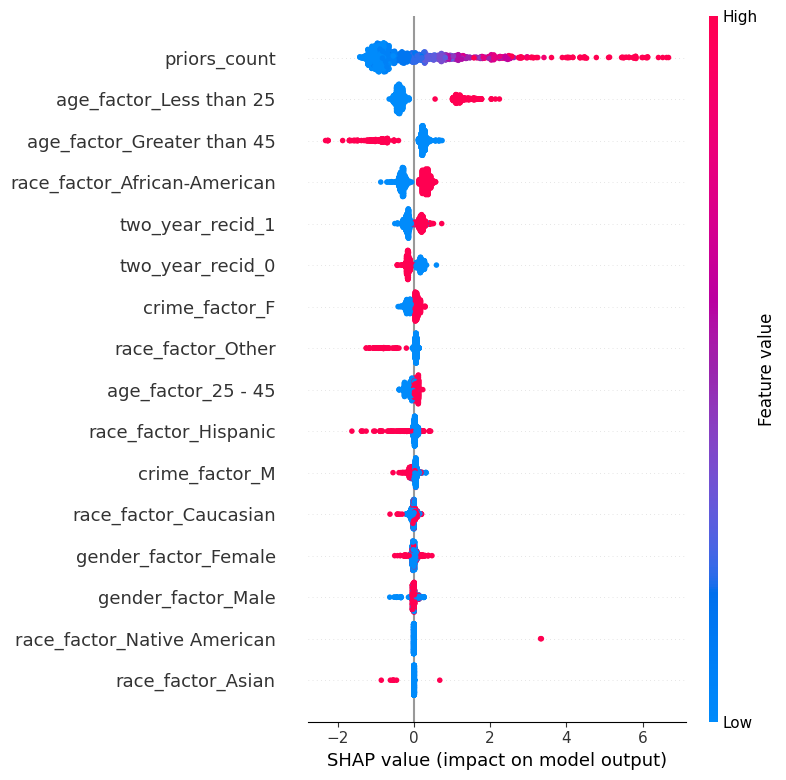

In [ ]:
import shap
import matplotlib.pyplot as plt # Add this as it's good practice for plotting cells
import numpy as np # Import numpy for type checking

# Re-transform X_test to X_test_enc and then to X_test_dense
X_test_enc = preprocessor.transform(X_test)
if hasattr(X_test_enc, "toarray"):
    X_test_dense = X_test_enc.toarray()
else:
    X_test_dense = X_test_enc

# Re-define feat_names to ensure consistency with the preprocessor
feat_names = (
    numeric_features +
    list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(
            category_features
        )
    )
)

# Re-initialize the SHAP explainer and calculate shap_values
# This uses TreeExplainer for the GBT classifier, which returns a list of arrays for binary classification.
explainer_shap = shap.TreeExplainer(gbt_pipeline["classifier"])
shap_values = explainer_shap.shap_values(X_test_dense, check_additivity=False)


# For binary classification with TreeExplainer, shap_values is often a list of two arrays.
# Select the SHAP values for the positive class (index 1) for plotting.
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] # Assuming class 1 is the positive class
elif isinstance(shap_values, shap.Explanation):
    # If shap_values is an Explanation object directly
    if shap_values.values.ndim == 3 and shap_values.values.shape[2] == 2:
        shap_values_plot = shap_values.values[:, :, 1] # Select values for the positive class (class 1)
    elif shap_values.values.ndim == 2:
        shap_values_plot = shap_values.values # Already 2D
    else:
        print("Warning: shap_values.values has unexpected dimensions for Explanation object. Attempting to use as-is.")
        shap_values_plot = shap_values.values # Attempt to use as-is, might still error
elif isinstance(shap_values, np.ndarray):
    # If shap_values is already a numpy array, use it directly
    shap_values_plot = shap_values
else:
    # Fallback for truly unexpected structures
    print("Warning: shap_values is in an unrecognized format. Attempting to use as-is.")
    shap_values_plot = shap_values

# Generate the beeswarm plot
shap.summary_plot(shap_values_plot, X_test_dense, feature_names=feat_names)


(b) a waterfall plot for the highest-risk
and lowest-risk defendant in each racial group.


--- SHAP Waterfall Plots for African-American defendants ---


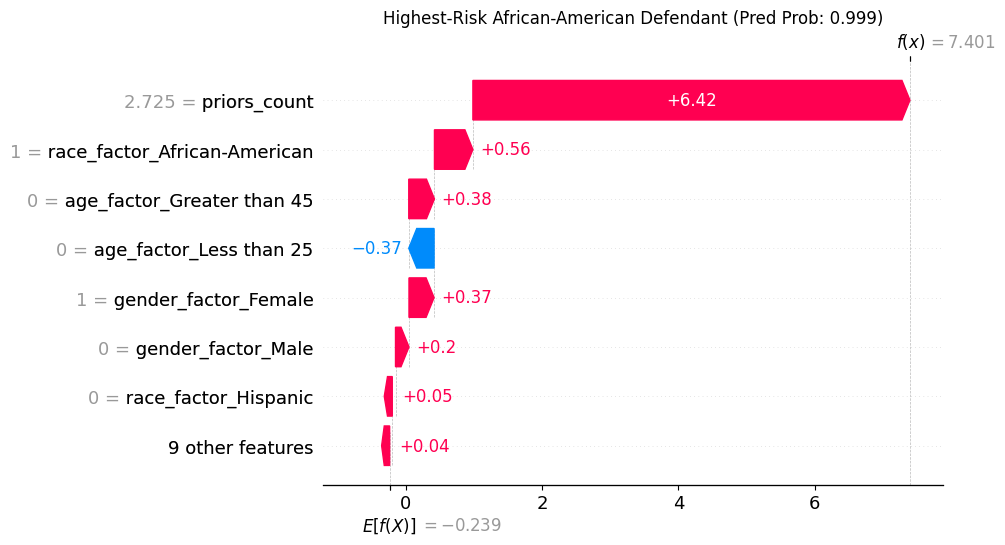

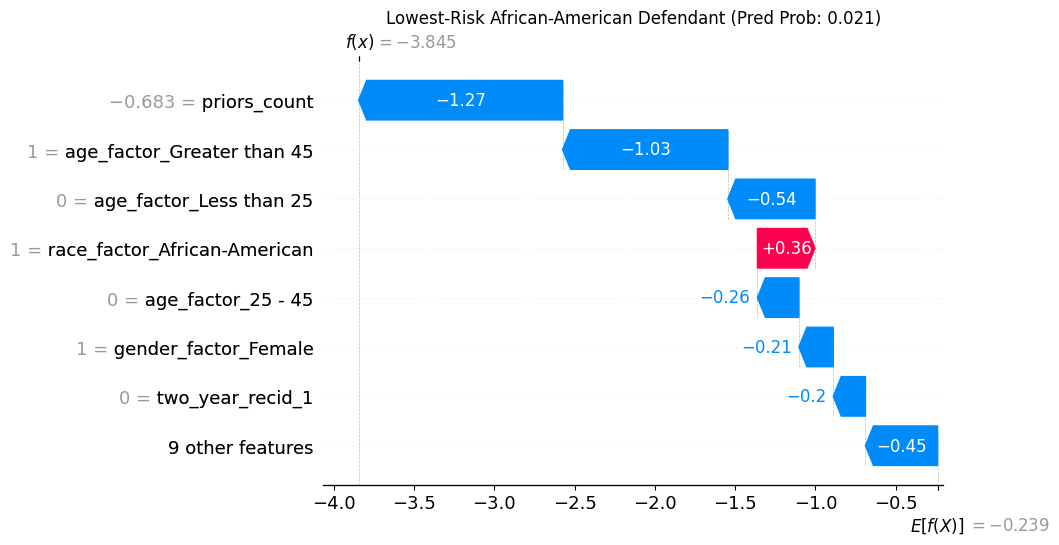


--- SHAP Waterfall Plots for Other defendants ---


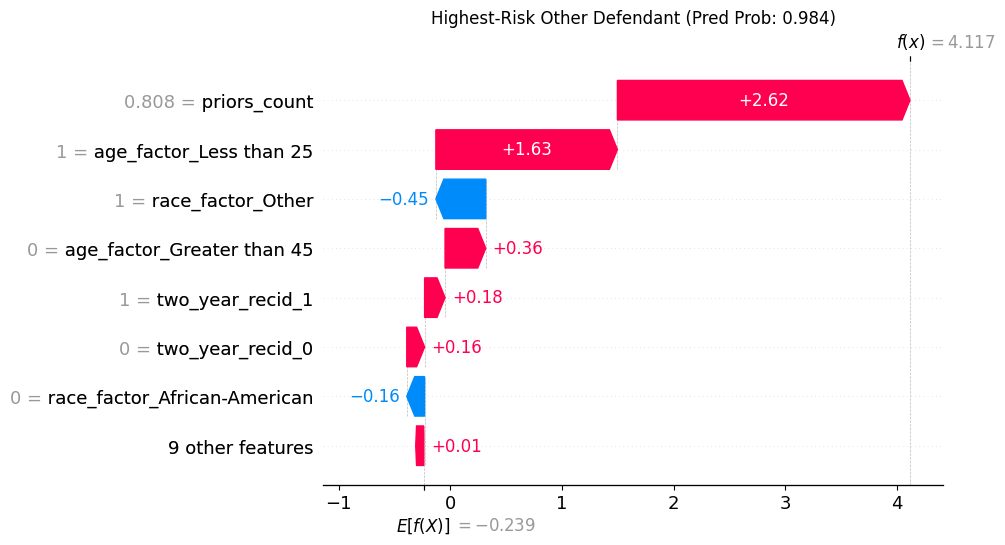

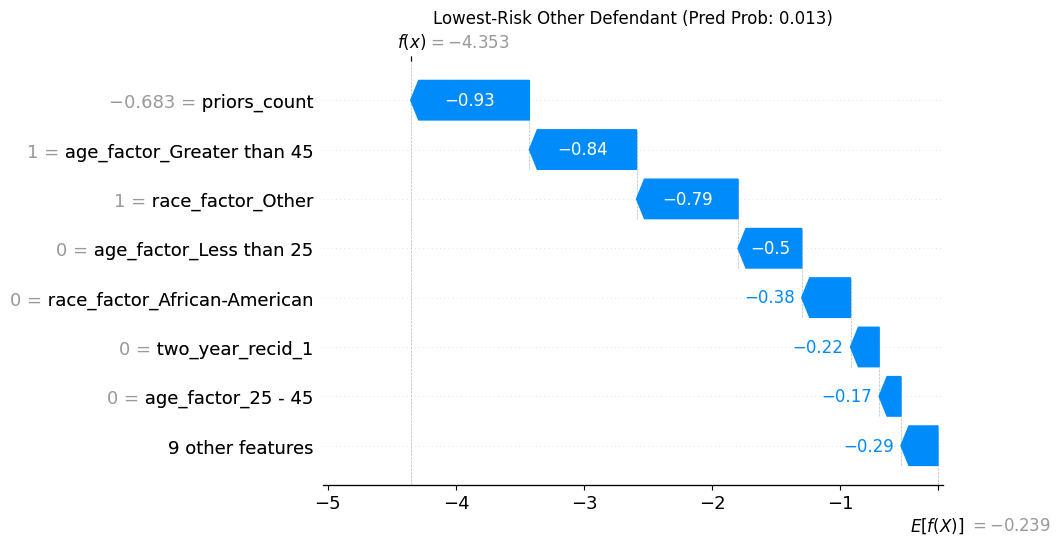


--- SHAP Waterfall Plots for Asian defendants ---


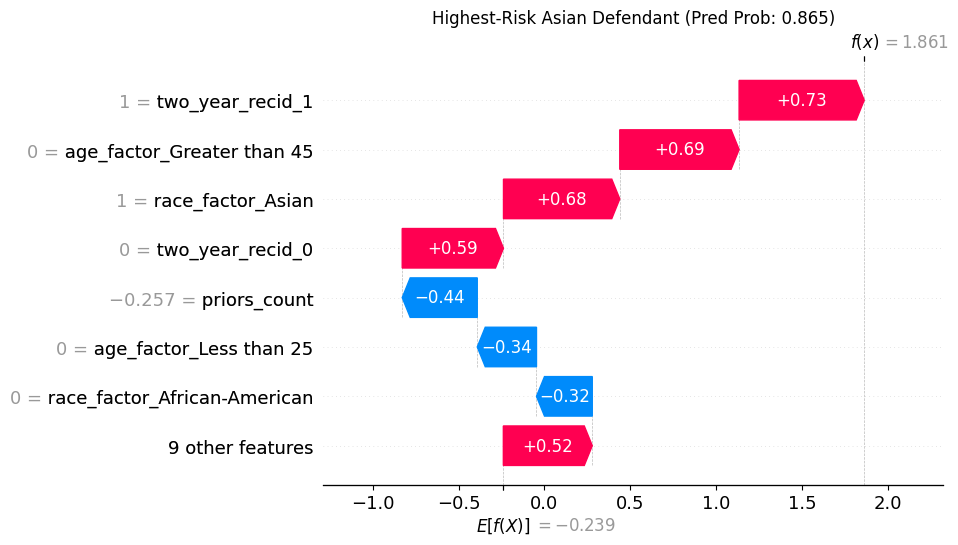

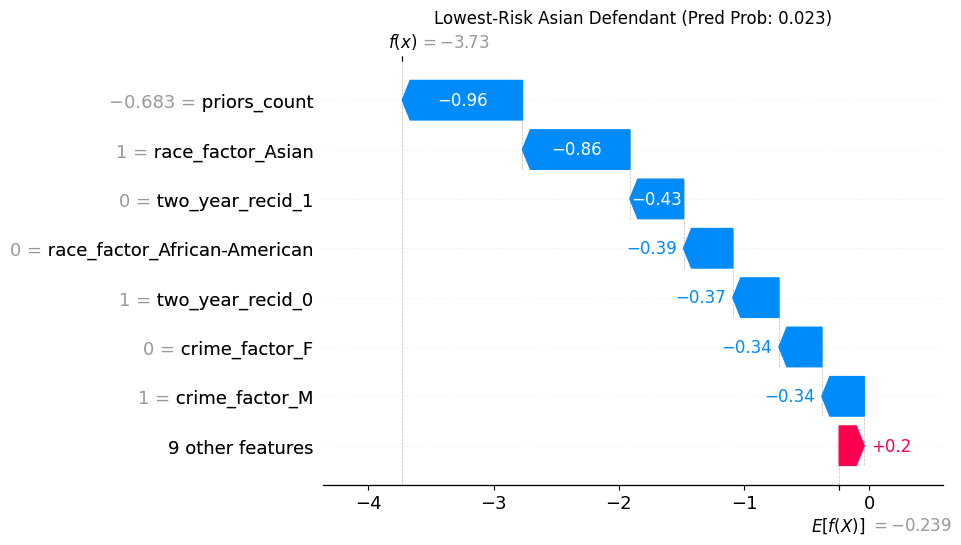


--- SHAP Waterfall Plots for Caucasian defendants ---


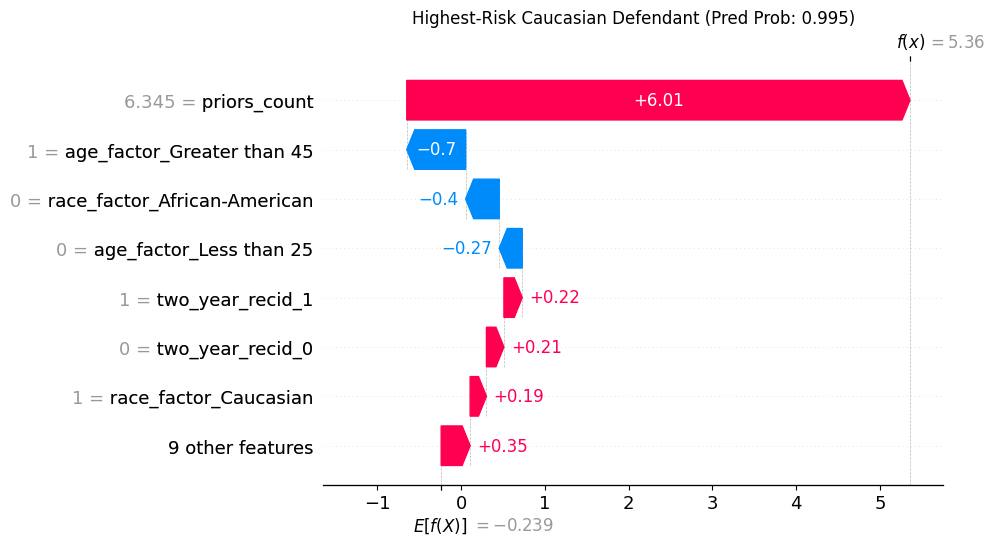

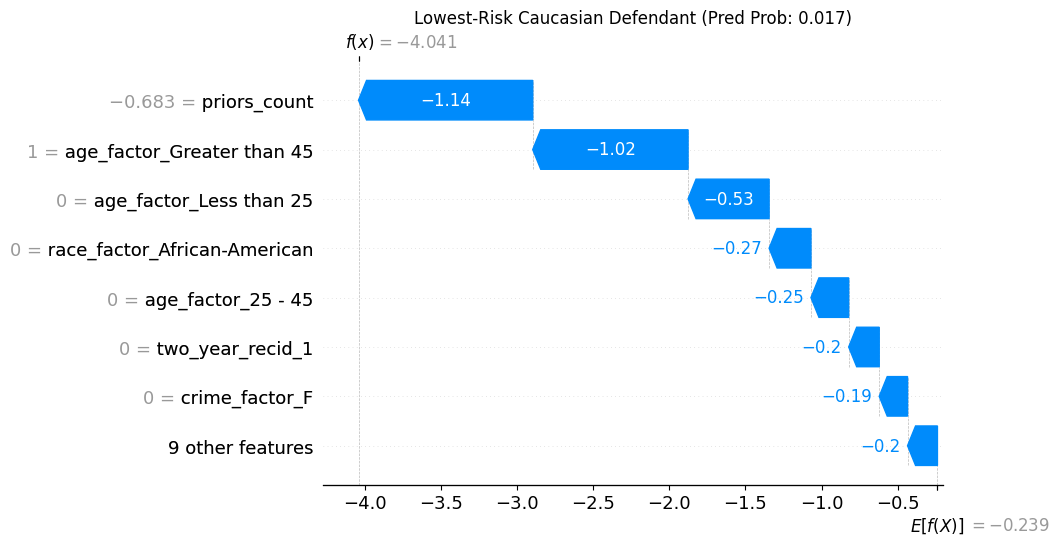


--- SHAP Waterfall Plots for Hispanic defendants ---


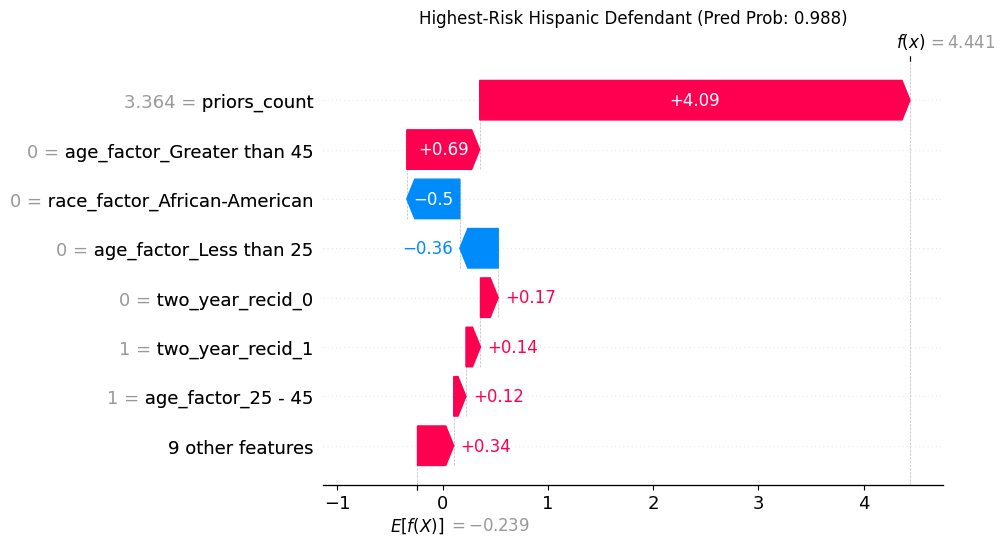

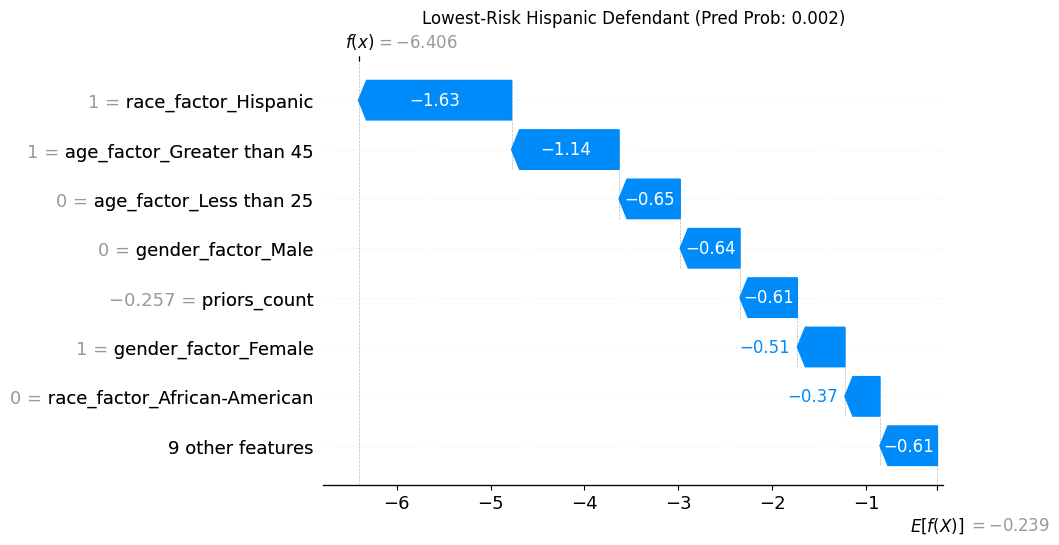


--- SHAP Waterfall Plots for Native American defendants ---


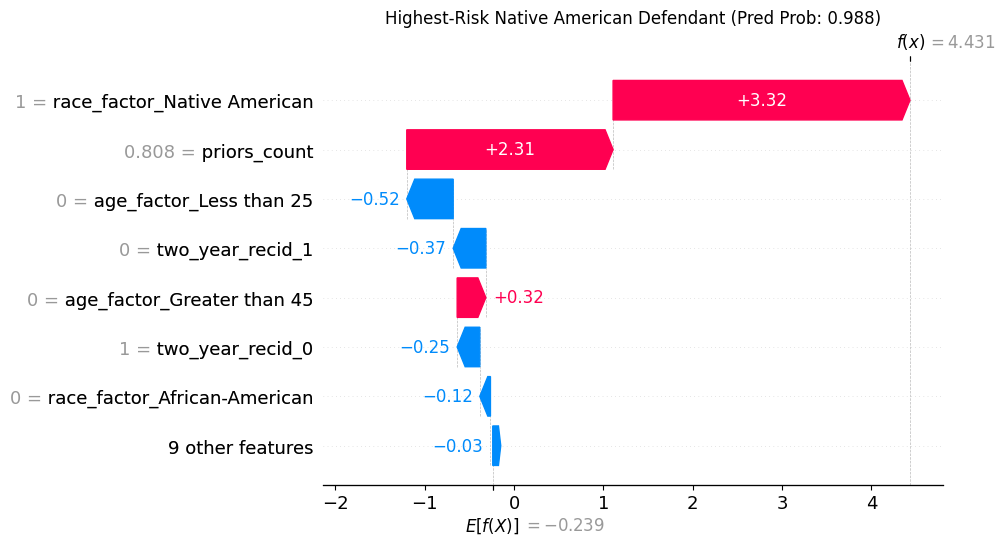

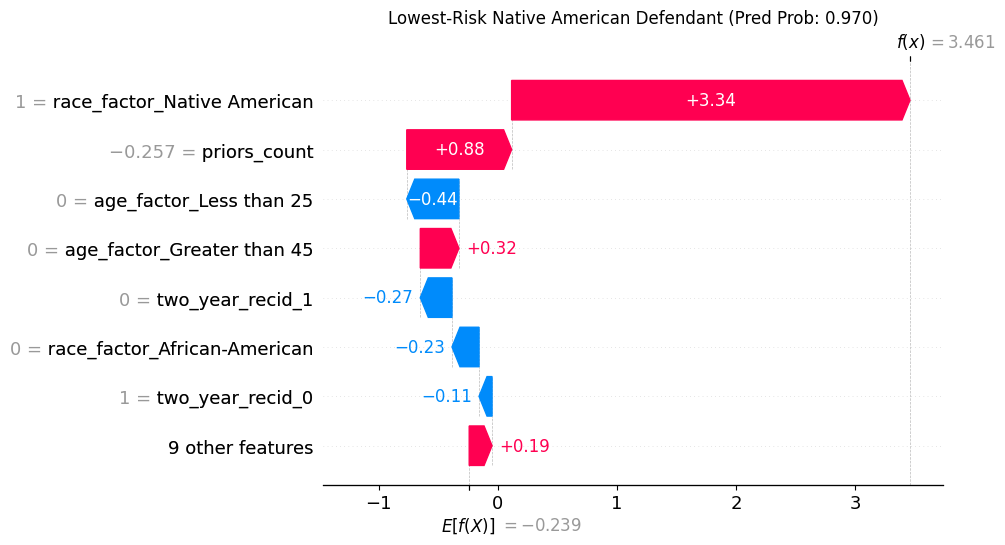

In [ ]:
import matplotlib.pyplot as plt
import shap

# Ensure X_test_copy has 'pred_prob' and 'race_factor' for filtering
# (It should already be available from previous cells)

# Get unique racial groups
race_groups = X_test_copy['race_factor'].unique()

for race in race_groups:
    # Filter data for the current race
    race_df = X_test_copy[X_test_copy['race_factor'] == race].copy()

    if len(race_df) == 0:
        continue

    # Sort by predicted probability to find highest and lowest risk
    highest_risk_df = race_df.sort_values(by='pred_prob', ascending=False).iloc[[0]]
    lowest_risk_df = race_df.sort_values(by='pred_prob', ascending=True).iloc[[0]]

    # Get original indices from X_test
    highest_risk_idx = highest_risk_df.index[0]
    lowest_risk_idx = lowest_risk_df.index[0]

    # Get locations in the encoded test set (X_test_enc)
    highest_risk_loc = X_test.index.get_loc(highest_risk_idx)
    lowest_risk_loc = X_test.index.get_loc(lowest_risk_idx)

    print(f"\n--- SHAP Waterfall Plots for {race} defendants ---")

    # Plot for Highest-Risk Defendant
    fig, ax = plt.subplots(figsize=(8, 5))
    plt.sca(ax)
    explanation_highest = shap.Explanation(
        values=shap_values[highest_risk_loc],
        base_values=explainer_shap.expected_value,
        data=X_test_enc[highest_risk_loc],
        feature_names=feat_names
    )
    shap.waterfall_plot(explanation_highest, max_display=8, show=False)
    ax.set_title(f"Highest-Risk {race} Defendant (Pred Prob: {highest_risk_df['pred_prob'].iloc[0]:.3f})")
    plt.show()

    # Plot for Lowest-Risk Defendant
    fig, ax = plt.subplots(figsize=(8, 5))
    plt.sca(ax)
    explanation_lowest = shap.Explanation(
        values=shap_values[lowest_risk_loc],
        base_values=explainer_shap.expected_value,
        data=X_test_enc[lowest_risk_loc],
        feature_names=feat_names
    )
    shap.waterfall_plot(explanation_lowest, max_display=8, show=False)
    ax.set_title(f"Lowest-Risk {race} Defendant (Pred Prob: {lowest_risk_df['pred_prob'].iloc[0]:.3f})")
    plt.show()

QUESTION 2: Run LIME on the same four individuals. Compare LIME and SHAP
feature attributions. Where do they agree? Where do they diverge?
What does divergence imply for governance?

In [ ]:
import matplotlib.pyplot as plt
import shap

# Get unique racial groups (African-American and Caucasian specifically for this task)
races_to_analyze = ['African-American', 'Caucasian']

for race in races_to_analyze:
    # Filter data for the current race
    race_df = X_test_copy[X_test_copy['race_factor'] == race].copy()

    if len(race_df) == 0:
        continue

    # Sort by predicted probability to find highest and lowest risk
    highest_risk_row = race_df.sort_values(by='pred_prob', ascending=False).iloc[[0]]
    lowest_risk_row = race_df.sort_values(by='pred_prob', ascending=True).iloc[[0]]

    individuals = [
        ("highest-risk", highest_risk_row),
        ("lowest-risk", lowest_risk_row)
    ]

    for risk_type, row_df in individuals:
        original_idx = row_df.index[0]
        instance_data = X_test.loc[[original_idx]]
        row_enc = preprocessor.transform(instance_data)

        # Use explainer_lime here
        exp = explainer_lime.explain_instance(
            data_row=row_enc[0],
            predict_fn=gbt_pipeline["classifier"].predict_proba,
            num_features=6 # Display top 6 features
        )

        print(f"\n── LIME: {race} {risk_type} defendant (Predicted Probability: {row_df['pred_prob'].iloc[0]:.3f}) ─────────────────────────")
        for feat, weight in exp.as_list():
            print(f"{feat:<40} {weight:+.4f}")

        # Optional: Print SHAP values for comparison (re-using the logic for single instance SHAP plot, but just printing values)
        # For comparison, let's also print the top SHAP values for these instances.
        # The `X_test.index.get_loc(original_idx)` finds the position in the X_test_enc array
        shap_loc = X_test.index.get_loc(original_idx)
        # Correctly access the numerical values from the shap.Explanation object

        # Ensure shap_values is handled correctly (list for binary classification)
        if isinstance(shap_values, list):
            instance_shap_values_numeric = shap_values[1][shap_loc]
        else:
            instance_shap_values_numeric = shap_values[shap_loc]

        # Create a list of (feature_name, shap_value) tuples
        shap_feature_importance = list(zip(feat_names, instance_shap_values_numeric))
        # Sort by absolute SHAP value to get the most impactful features
        shap_feature_importance_sorted = sorted(shap_feature_importance, key=lambda x: abs(x[1]), reverse=True)

        print(f"\n── SHAP Top Features: {race} {risk_type} defendant ─────────────────────────────")
        for feat, value in shap_feature_importance_sorted[:6]: # Print top 6 SHAP features
            print(f"{feat:<40} {value:+.4f}")


── LIME: African-American highest-risk defendant (Predicted Probability: 0.999) ─────────────────────────
race_factor_Native American <= 0.00      -0.4121
priors_count > 0.17                      +0.3825
age_factor_Less than 25 <= 0.00          -0.3332
age_factor_Greater than 45 <= 0.00       +0.2176
0.00 < race_factor_African-American <= 1.00 +0.1051
0.00 < two_year_recid_0 <= 1.00          -0.0449

── SHAP Top Features: African-American highest-risk defendant ─────────────────────────────
priors_count                             +6.4174
race_factor_African-American             +0.5645
age_factor_Greater than 45               +0.3772
age_factor_Less than 25                  -0.3716
gender_factor_Female                     +0.3683
gender_factor_Male                       +0.1979

── LIME: African-American lowest-risk defendant (Predicted Probability: 0.021) ─────────────────────────
age_factor_Less than 25 <= 0.00          -0.3467
age_factor_Greater than 45 > 0.00        -0.2291
0.00 


LIME and SHAP generally agree on the most important features, particularly priors_count and age_factor, which strongly influence risk predictions across individuals. Both methods show that higher prior offenses increase risk, while older age tends to reduce it.

However, they diverge in how they treat race_factor. SHAP assigns a more consistent and stronger contribution of race, especially for African-American defendants, while LIME shows more variability and context-dependent effects. LIME also uses rule-based thresholds, whereas SHAP provides stable additive contributions.

This divergence implies that relying on a single method may be misleading. For governance, it is important to use multiple interpretability tools and combine them with fairness metrics to ensure robust detection of bias and more reliable model oversight.

QUESTION 3: Generate at least one counterfactual per individual using DiCE
(Python) or NICE (R). Report the minimal feature changes required
to flip the prediction. Flag any counterfactuals that require changes
to immutable features (race, sex).

In [ ]:
import dice_ml
from dice_ml import Dice
import pandas as pd
import numpy as np

# Define immutable features that should not be varied for counterfactuals
IMMUTABLE_FEATURES = ['race_factor', 'gender_factor']

# Define mutable features that DiCE can vary
# These are selected based on the features used in the GBT model and what can be hypothetically changed.
FEATURES_TO_VARY_FOR_CF = [
    'age_factor',
    'priors_count',
    'crime_factor' # Treating crime_factor as hypothetically mutable for counterfactual generation
]

# Permitted range for features that can be varied by DiCE
permitted_range_for_dice = {
    "age_factor": ['25 - 45', 'Greater than 45', 'Less than 25'], # Categories for age_factor
    "priors_count": [0, 38], # Range of priors_count observed in the dataset
    "crime_factor": ['F', 'M'] # Categories for crime_factor (Felony, Misdemeanor)
}

# Re-initialize dice_data and exp_dice if they are not in the kernel state
# This ensures the code is robust if run independently or if kernel state changes.
if 'dice_data' not in locals() or 'exp_dice' not in locals():
    # X_train, y_train, numeric_features, target, gbt_pipeline should be available from earlier cells
    dice_data = dice_ml.Data(
        dataframe=pd.concat([X_train, y_train], axis=1), # Concatenate X_train and y_train for DiCE Data object
        continuous_features=numeric_features,
        outcome_name=target
    )
    dice_model = dice_ml.Model(
        model=gbt_pipeline,
        backend="sklearn",
        model_type="classifier"
    )
    exp_dice = Dice(dice_data, dice_model, method="random")

print("── DiCE Counterfactuals ────────────────────────────────────────────────")

# Identify the four specific individuals
races_to_analyze = ['African-American', 'Caucasian']
individuals_to_analyze = []

for race in races_to_analyze:
    race_df = X_test_copy[X_test_copy['race_factor'] == race].copy()

    if len(race_df) == 0:
        continue

    # Highest-risk for the current race
    highest_risk_row = race_df.sort_values(by='pred_prob', ascending=False).iloc[[0]]
    highest_risk_idx = highest_risk_row.index[0]
    individuals_to_analyze.append((f"{race} highest-risk defendant", highest_risk_idx))

    # Lowest-risk for the current race
    lowest_risk_row = race_df.sort_values(by='pred_prob', ascending=True).iloc[[0]]
    lowest_risk_idx = lowest_risk_row.index[0]
    individuals_to_analyze.append((f"{race} lowest-risk defendant", lowest_risk_idx))

for label, idx in individuals_to_analyze:
    # Retrieve the query instance from the test set using its original index
    query_instance = X_test.loc[[idx]]

    # Get the original prediction and its probability from the GBT model
    original_prediction = gbt_pipeline.predict(query_instance)[0] # 0 for LowScore, 1 for HighScore
    original_prob = gbt_pipeline.predict_proba(query_instance)[:, original_prediction][0]

    # Determine the desired class to flip the prediction for printing
    desired_class_for_print = 1 - original_prediction # If 0, desire 1; if 1, desire 0
    desired_class_name = "Recid" if desired_class_for_print == 1 else "No Recid"

    print(f"\n--- Counterfactuals for {label} ---")
    print(f"Original Prediction: {original_prediction} (Prob: {original_prob:.3f})")
    print(f"Seeking to flip to: {desired_class_for_print} ({desired_class_name})")

    # Generate counterfactuals
    cf = exp_dice.generate_counterfactuals(
        query_instance,
        total_CFs=1, # Requesting at least one counterfactual
        desired_class="opposite", # Use 'opposite' to let DiCE handle the class flipping
        permitted_range=permitted_range_for_dice,
        features_to_vary=FEATURES_TO_VARY_FOR_CF
    )

    print("Minimal feature changes to flip the prediction:")
    # Visualize the counterfactuals, showing only the changed features
    cf.visualize_as_dataframe(show_only_changes=True)

    # Flag any counterfactuals that require changes to immutable features.
    # Since IMMUTABLE_FEATURES are explicitly excluded from FEATURES_TO_VARY_FOR_CF,
    # DiCE will not attempt to change them. We report this explicitly.
    print(f"Note: Immutable features (race_factor, gender_factor) were kept constant (not varied) as requested.")

── DiCE Counterfactuals ────────────────────────────────────────────────

--- Counterfactuals for African-American highest-risk defendant ---
Original Prediction: 1 (Prob: 0.999)
Seeking to flip to: 0 (No Recid)


100%|██████████| 1/1 [00:00<00:00,  2.50it/s]

Minimal feature changes to flip the prediction:
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,25 - 45,African-American,16,F,NaN,1



Diverse Counterfactual set (new outcome: 0)


...

Minimal feature changes to flip the prediction:
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,Greater than 45,Caucasian,0,M,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,Less than 25,-,22,-,0,1


Note: Immutable features (race_factor, gender_factor) were kept constant (not varied) as requested.
